In [1]:
from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("/home/ganchao/Desktop/traj_decoding/trajectory-decoding")
sys.path.insert(0, str(REPO_DIR))

DATA_DIR = REPO_DIR / "data/m96z_calltype/m96z_U333_uma_smooth_sigma5_z"
CKPT_DIR = REPO_DIR / "checkpoints/m96z_U333_uma_smooth_sigma5_z_d64_l2_s32_e100"

D_MODEL = 64
N_LAYERS = 2
D_STATE = 32

print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("CKPT_DIR:", CKPT_DIR, CKPT_DIR.exists())
print("encoder:", (CKPT_DIR / "encoder.pt").exists())
print("autoencoder:", (CKPT_DIR / "autoencoder.pt").exists())

DATA_DIR: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U333_uma_smooth_sigma5_z True
CKPT_DIR: /home/ganchao/Desktop/traj_decoding/trajectory-decoding/checkpoints/m96z_U333_uma_smooth_sigma5_z_d64_l2_s32_e100 True
encoder: True
autoencoder: True


In [2]:
def parse_ts_file(path):
    path = Path(path)
    text = path.read_text(errors="ignore")

    class_names = None
    class_to_id = None
    X = []
    y = []
    in_data = False

    for line in text.splitlines():
        line = line.strip()

        if len(line) == 0 or line.startswith("#"):
            continue

        if line.lower().startswith("@classlabel"):
            parts = line.split()
            class_names = parts[2:]
            class_to_id = {c: i for i, c in enumerate(class_names)}
            continue

        if line.lower().startswith("@data"):
            in_data = True
            continue

        if line.startswith("@") or not in_data:
            continue

        parts = line.split(":")
        label = parts[-1].strip()
        dim_parts = parts[:-1]

        dims = []
        for dp in dim_parts:
            vals = [float(v) for v in dp.split(",") if v != ""]
            dims.append(vals)

        X.append(np.asarray(dims, dtype=np.float32).T)
        y.append(class_to_id[label])

    return np.stack(X), np.asarray(y, dtype=np.int64), class_names


def load_ts_dataset(data_dir):
    data_dir = Path(data_dir)

    train_files = sorted(data_dir.glob("*_TRAIN.ts"))
    assert len(train_files) == 1, f"Expected one TRAIN file, found {len(train_files)}"

    train_path = train_files[0]
    test_path = train_path.with_name(train_path.name.replace("_TRAIN.ts", "_TEST.ts"))

    X_train, y_train, class_names_train = parse_ts_file(train_path)
    X_test, y_test, class_names_test = parse_ts_file(test_path)

    assert class_names_train == class_names_test
    assert X_train.shape[1:] == X_test.shape[1:]

    return X_train, y_train, X_test, y_test, class_names_train


X_train, y_train, X_test, y_test, class_names = load_ts_dataset(DATA_DIR)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("classes:", class_names)

for k, name in enumerate(class_names):
    print(f"{name:12s}", "train", np.sum(y_train == k), "test", np.sum(y_test == k))

X_train: (160, 1416, 32)
X_test : (40, 1416, 32)
classes: ['phee', 'twitter', 'trill', 'trill_phee']
phee         train 40 test 10
twitter      train 40 test 10
trill        train 40 test 10
trill_phee   train 40 test 10


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def eval_classifier(name, y_true, pred, class_names):
    acc = accuracy_score(y_true, pred)
    correct = int(np.sum(pred == y_true))
    total = len(y_true)

    print()
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"accuracy = {acc:.3f} ({correct}/{total})")
    print()
    print(classification_report(
        y_true,
        pred,
        target_names=class_names,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, pred, labels=np.arange(len(class_names)))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"{name}, acc={acc:.3f}")
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "acc": acc,
        "correct": correct,
        "total": total,
    }

# 1. Trial-level PCA
dim of data points: time $\times$ units

,model,n_pc,feature_dim,acc,correct,total
3,PCA,20,20,0.975,39,40
2,PCA,10,10,0.950,38,40
4,PCA,50,50,0.900,36,40
5,PCA,100,100,0.900,36,40
1,PCA,5,5,0.850,34,40
0,PCA,2,2,0.525,21,40



PCA + SVM, n_pc=20
accuracy = 0.975 (39/40)

              precision    recall  f1-score   support

        phee       1.00      1.00      1.00        10
     twitter       1.00      1.00      1.00        10
       trill       1.00      0.90      0.95        10
  trill_phee       0.91      1.00      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



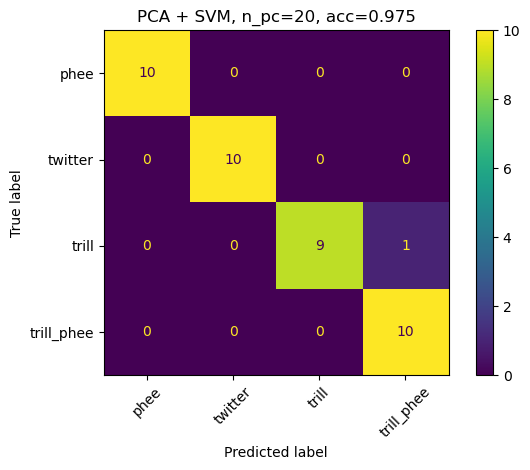

In [4]:
Xtr_flat = X_train.reshape(X_train.shape[0], -1)
Xte_flat = X_test.reshape(X_test.shape[0], -1)

pca_rows = []
pca_store = {}

for n_pc in [2, 5, 10, 20, 50, 100]:
    n_pc_use = min(n_pc, X_train.shape[0] - 1, Xtr_flat.shape[1])

    clf = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_pc_use),
        SVC(kernel="rbf", C=10.0, gamma="scale"),
    )

    clf.fit(Xtr_flat, y_train)
    pred = clf.predict(Xte_flat)

    acc = accuracy_score(y_test, pred)

    pca_rows.append({
        "model": "PCA",
        "n_pc": n_pc_use,
        "feature_dim": n_pc_use,
        "acc": acc,
        "correct": int(np.sum(pred == y_test)),
        "total": len(y_test),
    })

    pca_store[n_pc_use] = {
        "clf": clf,
        "pred": pred,
    }

pca_df = pd.DataFrame(pca_rows)
display(pca_df.sort_values("acc", ascending=False))

best_pca = pca_df.sort_values("acc", ascending=False).iloc[0]
best_pca_pred = pca_store[int(best_pca["n_pc"])]["pred"]

pca_summary = eval_classifier(
    f"PCA + SVM, n_pc={int(best_pca['n_pc'])}",
    y_test,
    best_pca_pred,
    class_names,
)
pca_summary["model"] = "PCA"
pca_summary["setting"] = f"n_pc={int(best_pca['n_pc'])}"

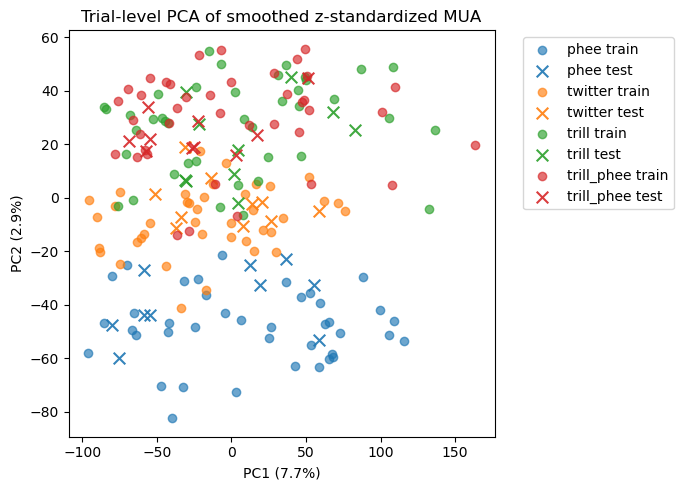

In [5]:
# Fit PCA on training trials only, then transform train and test.

scaler_trial = StandardScaler()
Xtr_s = scaler_trial.fit_transform(Xtr_flat)
Xte_s = scaler_trial.transform(Xte_flat)

pca_trial = PCA(n_components=10)
Ztr_trial = pca_trial.fit_transform(Xtr_s)
Zte_trial = pca_trial.transform(Xte_s)

# plt.figure(figsize=(7, 5))

# for k, cls in enumerate(class_names):
#     mtr = y_train == k
#     mte = y_test == k

#     plt.scatter(
#         Ztr_trial[mtr, 0],
#         Ztr_trial[mtr, 1],
#         alpha=0.65,
#         label=f"{cls} train",
#     )
#     plt.scatter(
#         Zte_trial[mte, 0],
#         Zte_trial[mte, 1],
#         marker="x",
#         s=70,
#         label=f"{cls} test",
#     )

# plt.xlabel(f"PC1 ({pca_trial.explained_variance_ratio_[0]:.1%})")
# plt.ylabel(f"PC2 ({pca_trial.explained_variance_ratio_[1]:.1%})")
# plt.title("Trial-level PCA of smoothed z-standardized MUA")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.tight_layout()
# plt.show()

# Trial-level PCA figure: same color for call type, different marker for train/test

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
class_colors = {
    cls: color_cycle[k % len(color_cycle)]
    for k, cls in enumerate(class_names)
}

plt.figure(figsize=(7, 5))

for k, cls in enumerate(class_names):
    mtr = y_train == k
    mte = y_test == k

    plt.scatter(
        Ztr_trial[mtr, 0],
        Ztr_trial[mtr, 1],
        alpha=0.65,
        marker="o",
        color=class_colors[cls],
        label=f"{cls} train",
    )

    plt.scatter(
        Zte_trial[mte, 0],
        Zte_trial[mte, 1],
        alpha=0.90,
        marker="x",
        s=70,
        color=class_colors[cls],
        label=f"{cls} test",
    )

plt.xlabel(f"PC1 ({pca_trial.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_trial.explained_variance_ratio_[1]:.1%})")
plt.title("Trial-level PCA of smoothed z-standardized MUA")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2. Time-stacked PCA
data dim = unit

In [6]:
Ntr, T, D = X_train.shape
Nte = X_test.shape[0]

Xtr_time = X_train.reshape(-1, D)
Xte_time = X_test.reshape(-1, D)

time_scaler = StandardScaler()
Xtr_time_s = time_scaler.fit_transform(Xtr_time)
Xte_time_s = time_scaler.transform(Xte_time)

N_PC_TIME_MAX = min(D, 32)

time_pca = PCA(n_components=N_PC_TIME_MAX)
Ztr_time = time_pca.fit_transform(Xtr_time_s).reshape(Ntr, T, N_PC_TIME_MAX)
Zte_time = time_pca.transform(Xte_time_s).reshape(Nte, T, N_PC_TIME_MAX)

print("Ztr_time:", Ztr_time.shape)
print("Zte_time:", Zte_time.shape)
print("time-PC explained first 10:")
print(time_pca.explained_variance_ratio_[:10])
print("cumulative first 10:")
print(np.cumsum(time_pca.explained_variance_ratio_[:10]))

Ztr_time: (160, 1416, 32)
Zte_time: (40, 1416, 32)
time-PC explained first 10:
[0.16725539 0.10477239 0.05328658 0.04448416 0.03752526 0.03580042
 0.03379276 0.03214477 0.03090669 0.03058926]
cumulative first 10:
[0.16725539 0.2720278  0.32531437 0.36979854 0.4073238  0.44312423
 0.476917   0.50906175 0.53996843 0.5705577 ]


,model,n_pc,feature_dim,acc,correct,total
3,time-stacked PCA summary,10,40,0.975,39,40
4,time-stacked PCA summary,20,80,0.975,39,40
5,time-stacked PCA summary,30,120,0.975,39,40
2,time-stacked PCA summary,5,20,0.825,33,40
1,time-stacked PCA summary,3,12,0.600,24,40
0,time-stacked PCA summary,2,8,0.300,12,40



Time-stacked PCA summary + SVM, n_pc=10
accuracy = 0.975 (39/40)

              precision    recall  f1-score   support

        phee       1.00      1.00      1.00        10
     twitter       0.91      1.00      0.95        10
       trill       1.00      1.00      1.00        10
  trill_phee       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



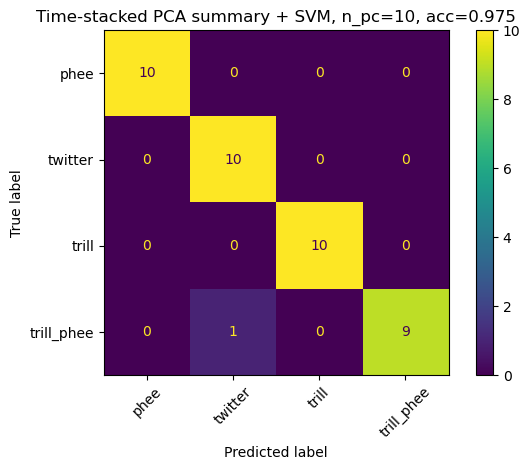

In [7]:
def make_time_pca_summary_features(Z, n_pc):
    Zk = Z[:, :, :n_pc]

    feat = np.concatenate(
        [
            Zk.mean(axis=1),
            Zk.std(axis=1),
            Zk.min(axis=1),
            Zk.max(axis=1),
        ],
        axis=1,
    )

    return feat


time_rows = []
time_store = {}

for n_pc in [2, 3, 5, 10, 20, 30]:
    n_pc_use = min(n_pc, N_PC_TIME_MAX)

    F_train = make_time_pca_summary_features(Ztr_time, n_pc_use)
    F_test = make_time_pca_summary_features(Zte_time, n_pc_use)

    clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=10.0, gamma="scale"),
    )

    clf.fit(F_train, y_train)
    pred = clf.predict(F_test)

    acc = accuracy_score(y_test, pred)

    time_rows.append({
        "model": "time-stacked PCA summary",
        "n_pc": n_pc_use,
        "feature_dim": F_train.shape[1],
        "acc": acc,
        "correct": int(np.sum(pred == y_test)),
        "total": len(y_test),
    })

    time_store[n_pc_use] = {
        "clf": clf,
        "pred": pred,
        "F_train": F_train,
        "F_test": F_test,
    }

time_df = pd.DataFrame(time_rows)
display(time_df.sort_values("acc", ascending=False))

best_time = time_df.sort_values("acc", ascending=False).iloc[0]
best_time_pred = time_store[int(best_time["n_pc"])]["pred"]

time_summary = eval_classifier(
    f"Time-stacked PCA summary + SVM, n_pc={int(best_time['n_pc'])}",
    y_test,
    best_time_pred,
    class_names,
)
time_summary["model"] = "time-stacked PCA"
time_summary["setting"] = f"summary, n_pc={int(best_time['n_pc'])}"

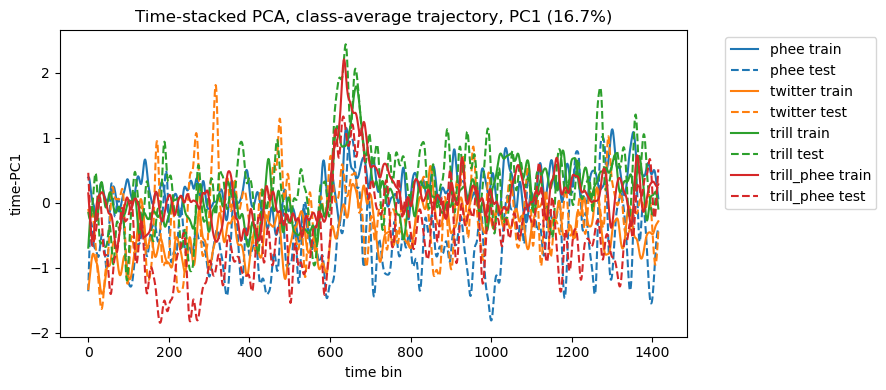

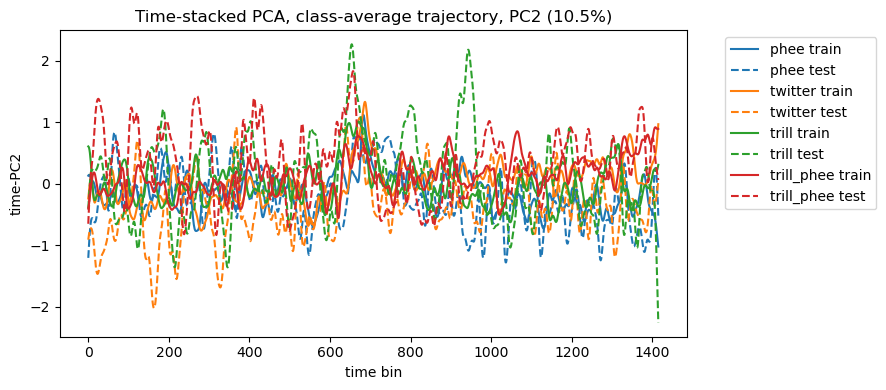

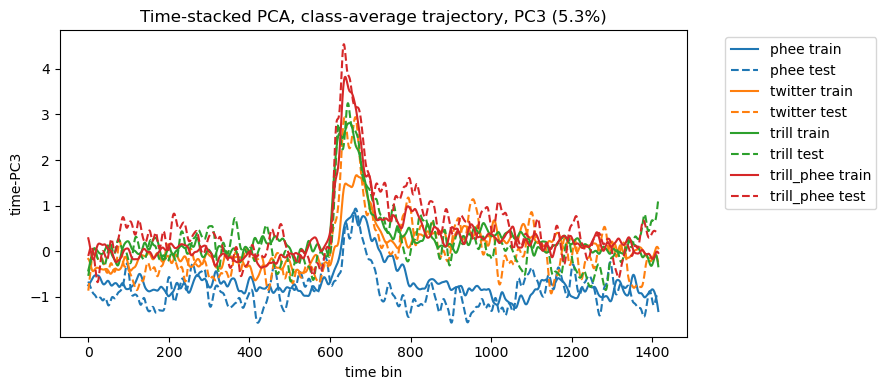

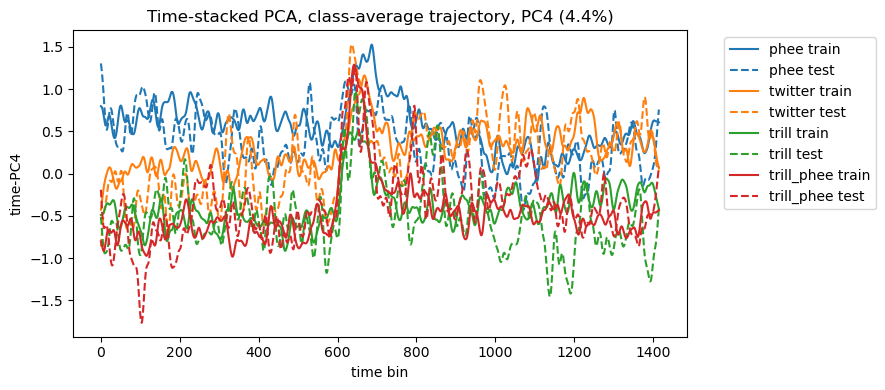

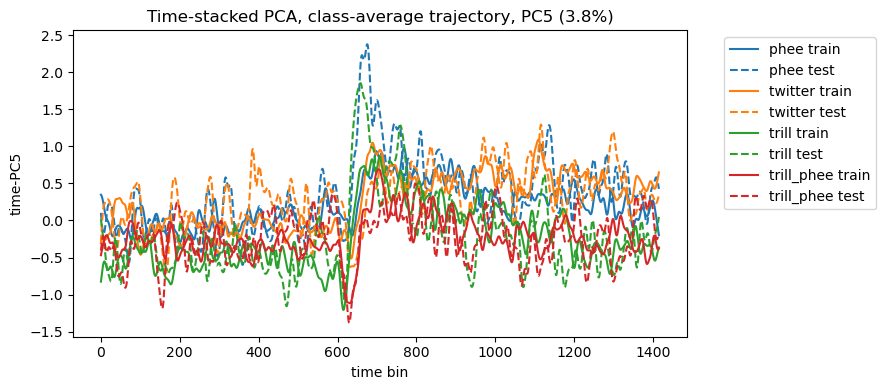

In [8]:
# Time-stacked PCA trajectories:
# same color for call type, solid=train, dashed=test

N_PC_SHOW = 5

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
class_colors = {
    cls: color_cycle[k % len(color_cycle)]
    for k, cls in enumerate(class_names)
}

for pc in range(N_PC_SHOW):
    plt.figure(figsize=(9, 4))

    for k, cls in enumerate(class_names):
        train_mean = Ztr_time[y_train == k, :, pc].mean(axis=0)
        test_mean = Zte_time[y_test == k, :, pc].mean(axis=0)

        plt.plot(
            train_mean,
            color=class_colors[cls],
            linestyle="-",
            label=f"{cls} train",
        )

        plt.plot(
            test_mean,
            color=class_colors[cls],
            linestyle="--",
            label=f"{cls} test",
        )

    plt.xlabel("time bin")
    plt.ylabel(f"time-PC{pc + 1}")
    plt.title(
        f"Time-stacked PCA, class-average trajectory, "
        f"PC{pc + 1} ({time_pca.explained_variance_ratio_[pc]:.1%})"
    )
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from src.model import SequenceEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

class LocalTrajectoryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.X[idx].shape[0], self.y[idx]

def local_collate_fn(batch):
    seqs, lengths, labels = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.int64)
    padded = pad_sequence(list(seqs), batch_first=True)
    labels = torch.stack(labels)
    return padded, lengths, labels

@torch.no_grad()
def extract_embeddings(encoder, X, y, batch_size=16):
    loader = DataLoader(
        LocalTrajectoryDataset(X, y),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=local_collate_fn,
    )

    Zs = []
    ys = []

    encoder.eval()

    for seqs, lengths, labels in loader:
        seqs = seqs.to(device)
        lengths = lengths.to(device)

        z = encoder(seqs, lengths)

        Zs.append(z.cpu().numpy())
        ys.append(labels.numpy())

    return np.concatenate(Zs, axis=0), np.concatenate(ys, axis=0)


encoder = SequenceEncoder(
    input_dim=X_train.shape[-1],
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    d_state=D_STATE,
).to(device)

encoder_path = CKPT_DIR / "encoder.pt"
assert encoder_path.exists(), encoder_path

encoder.load_state_dict(torch.load(encoder_path, map_location=device))
encoder.eval()

Z_train, ytr = extract_embeddings(encoder, X_train, y_train)
Z_test, yte = extract_embeddings(encoder, X_test, y_test)

print("AE Z_train:", Z_train.shape)
print("AE Z_test :", Z_test.shape)

device: cuda
AE Z_train: (160, 64)
AE Z_test : (40, 64)



AE encoder embedding + SVM, d_model=64
accuracy = 0.750 (30/40)

              precision    recall  f1-score   support

        phee       0.90      0.90      0.90        10
     twitter       0.70      0.70      0.70        10
       trill       0.75      0.90      0.82        10
  trill_phee       0.62      0.50      0.56        10

    accuracy                           0.75        40
   macro avg       0.74      0.75      0.74        40
weighted avg       0.74      0.75      0.74        40



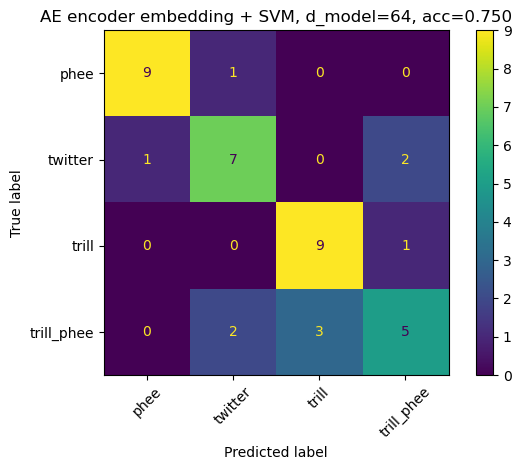

In [10]:
ae_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10.0, gamma="scale"),
)

ae_clf.fit(Z_train, ytr)
ae_pred = ae_clf.predict(Z_test)

ae_summary = eval_classifier(
    f"AE encoder embedding + SVM, d_model={D_MODEL}",
    yte,
    ae_pred,
    class_names,
)
ae_summary["model"] = "AE"
ae_summary["setting"] = f"d_model={D_MODEL}, layers={N_LAYERS}, d_state={D_STATE}"

AE embedding shape: (200, 64)
first 10 explained variance:
[0.1218368  0.08667782 0.06231647 0.05859961 0.05531513 0.05160584
 0.0429339  0.04242085 0.03855371 0.03565865]
cumulative first 10:
[0.1218368  0.20851463 0.2708311  0.3294307  0.38474584 0.4363517
 0.4792856  0.52170646 0.5602602  0.59591883]


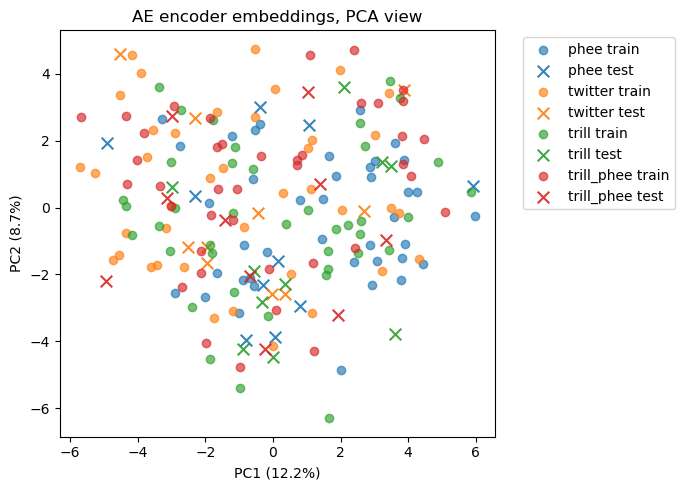

In [11]:
# AE embedding PCA figure:
# same color for call type, different marker for train/test

Z_all = np.concatenate([Z_train, Z_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
split = np.array(["train"] * len(y_train) + ["test"] * len(y_test))

Z0 = Z_all - Z_all.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Z0, full_matrices=False)
Z_pca = U * S
explained = S**2 / np.sum(S**2)

print("AE embedding shape:", Z_all.shape)
print("first 10 explained variance:")
print(explained[:10])
print("cumulative first 10:")
print(np.cumsum(explained[:10]))

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
class_colors = {
    cls: color_cycle[k % len(color_cycle)]
    for k, cls in enumerate(class_names)
}

plt.figure(figsize=(7, 5))

for k, cls in enumerate(class_names):
    mtr = (y_all == k) & (split == "train")
    mte = (y_all == k) & (split == "test")

    plt.scatter(
        Z_pca[mtr, 0],
        Z_pca[mtr, 1],
        alpha=0.65,
        marker="o",
        color=class_colors[cls],
        label=f"{cls} train",
    )

    plt.scatter(
        Z_pca[mte, 0],
        Z_pca[mte, 1],
        alpha=0.90,
        marker="x",
        s=70,
        color=class_colors[cls],
        label=f"{cls} test",
    )

plt.xlabel(f"PC1 ({explained[0]:.1%})")
plt.ylabel(f"PC2 ({explained[1]:.1%})")
plt.title("AE encoder embeddings, PCA view")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [12]:
# # AE embedding PCA pair plot for first 6 PCs

# N_PC_SHOW = 6

# fig, axes = plt.subplots(
#     N_PC_SHOW,
#     N_PC_SHOW,
#     figsize=(2.2 * N_PC_SHOW, 2.2 * N_PC_SHOW),
# )

# for i in range(N_PC_SHOW):
#     for j in range(N_PC_SHOW):
#         ax = axes[i, j]

#         if i == j:
#             for k, cls in enumerate(class_names):
#                 mask = y_all == k
#                 ax.hist(
#                     Z_pca[mask, i],
#                     bins=15,
#                     alpha=0.5,
#                     color=class_colors[cls],
#                     label=cls,
#                 )
#         else:
#             for k, cls in enumerate(class_names):
#                 mask = y_all == k
#                 ax.scatter(
#                     Z_pca[mask, j],
#                     Z_pca[mask, i],
#                     s=12,
#                     alpha=0.65,
#                     color=class_colors[cls],
#                 )

#         if i == N_PC_SHOW - 1:
#             ax.set_xlabel(f"PC{j + 1}")
#         if j == 0:
#             ax.set_ylabel(f"PC{i + 1}")

#         ax.tick_params(labelsize=7)

# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right")
# fig.suptitle("AE encoder embedding PCA pair plot")
# plt.tight_layout()
# plt.show()

In [13]:
final_df = pd.DataFrame([pca_summary, time_summary, ae_summary])

final_df = final_df[["model", "setting", "acc", "correct", "total"]]
display(final_df.sort_values("acc", ascending=False))

,model,setting,acc,correct,total
0,PCA,n_pc=20,0.975,39,40
1,time-stacked PCA,"summary, n_pc=10",0.975,39,40
2,AE,"d_model=64, layers=2, d_state=32",0.750,30,40
